# 01: Initial assessment of NYC HVFHV trip records

**Objective.** Characterize the dataset and establish the temporal and geographic scope for
subsequent analyses.

**Scope.** The analysis:
1. summarizes the available fields and quantifies the records retained after basic validity filters;
2. describes intraday variation in trip volume;
3. maps the geographic distribution of trip volume; and
4. compares the proportion of trips retained within candidate borough geofences.

Subsequent notebooks examine demand structure (02), heat-related changes in travel time (03),
Brooklyn spatial aggregation and zone-pair travel times (04), and demand-rate estimation, fleet
sizing, and capture share (05).

**Data.** New York City Taxi and Limousine Commission High Volume For Hire Vehicle trip records for
Uber and Lyft. This initial assessment uses June 2025. The fitted demand and travel artifacts in later
notebooks use June and July 2025. Both months follow the January 2025 introduction of Manhattan
congestion pricing and remain within one regulatory regime.

**Demand measure.** The records contain trips that were served and reported to the TLC. Requests
that did not result in a recorded trip are not observed. Trip counts therefore measure realized
demand rather than latent demand.

In [1]:
import duckdb, pandas as pd, geopandas as gpd, numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.colors import TwoSlopeNorm

from common import session, base_aggregate, parquet_path, CALIBRATION_MONTH, RAW
import vizstyle

vizstyle.apply()
pd.set_option("display.max_rows", 40)

con = session(CALIBRATION_MONTH)   # June working set for this initial assessment
print(f"duckdb {duckdb.__version__} · pandas {pd.__version__} · geopandas {gpd.__version__}")
print(f"month {CALIBRATION_MONTH} · {parquet_path().stat().st_size/1e6:.0f} MB on disk")

duckdb 1.5.5 · pandas 3.0.5 · geopandas 1.1.4
month 2025-06 · 491 MB on disk


## 1. Dataset schema

In [2]:
con.sql("DESCRIBE SELECT * FROM raw").df()[["column_name", "column_type"]]

,column_name,column_type
0,hvfhs_license_num,VARCHAR
1,dispatching_base_num,VARCHAR
2,originating_base_num,VARCHAR
3,request_datetime,TIMESTAMP
4,on_scene_datetime,TIMESTAMP
5,pickup_datetime,TIMESTAMP
6,dropoff_datetime,TIMESTAMP
7,PULocationID,INTEGER
8,DOLocationID,INTEGER
9,trip_miles,DOUBLE


### Variables used in subsequent analyses

| Column | Analytical use |
|---|---|
| `request_datetime` | Request submission time and demand arrival time |
| `on_scene_datetime` | Vehicle arrival time at the pickup location; used to measure observed wait |
| `pickup_datetime` | Start of the occupied trip and end of boarding dwell |
| `dropoff_datetime` | End of the occupied trip |
| `PULocationID` and `DOLocationID` | Origin and destination taxi zones |
| `trip_miles` | Reported occupied trip distance used in energy calculations |
| `trip_time` | Occupied trip duration used to estimate travel distributions |

Fare, payment, and provider accounting fields are outside the scope of the experimental inputs. Service
flags are used in later notebooks to describe or exclude specific trip types where their movement
differs from the modeled service.

## 2. Temporal coverage and data completeness

The initial quality assessment evaluates the file's temporal coverage and missingness in the
variables used in subsequent analyses.

In [3]:
con.sql("""
SELECT min(request_datetime)                  AS first_request,
       max(request_datetime)                  AS last_request,
       count(*)                               AS trips,
       sum(request_datetime  IS NULL)::BIGINT AS null_request,
       sum(on_scene_datetime IS NULL)::BIGINT AS null_on_scene,
       sum(pickup_datetime   IS NULL)::BIGINT AS null_pickup,
       sum(trip_miles <= 0)::BIGINT           AS zero_miles,
       sum(trip_time  <= 0)::BIGINT           AS zero_time
FROM raw
""").df().T.rename(columns={0: "value"})

,value
first_request,2025-05-31 23:25:40
last_request,2025-07-01 00:04:10
trips,19868009
null_request,0
null_on_scene,0
null_pickup,0
zero_miles,2500
zero_time,1


The analyzed timestamp fields are complete. This permits direct calculation of the interval from
request submission to vehicle arrival and avoids imputing the primary observed wait measure.

The file is partitioned by pickup time, so request timestamps extend slightly beyond the nominal June
boundary. The working set filters on `request_datetime` to preserve a complete June arrival window.

In [4]:
con.sql("""
SELECT hvfhs_license_num AS license,
       CASE hvfhs_license_num
            WHEN 'HV0002' THEN 'Juno' WHEN 'HV0003' THEN 'Uber'
            WHEN 'HV0004' THEN 'Via'  WHEN 'HV0005' THEN 'Lyft' END AS operator,
       count(*) AS trips,
       round(100.0 * count(*) / sum(count(*)) OVER (), 2) AS pct
FROM raw GROUP BY 1, 2 ORDER BY trips DESC
""").df()

,license,operator,trips,pct
0,HV0003,Uber,14167361,71.31
1,HV0005,Lyft,5700648,28.69


The analysis models aggregate HVFHV demand. Provider-specific differences are outside its
scope, so trips are pooled across operators.

## 3. Analytic sample

The analytic sample includes requests submitted in June 2025 with positive trip distance and
duration. `common.session()` applies these inclusion criteria across all notebooks.

In [5]:
total = con.sql("SELECT count(*) FROM raw").fetchone()[0]
kept  = con.sql("SELECT count(*) FROM t").fetchone()[0]
print(f"raw      {total:>12,}")
print(f"working  {kept:>12,}   ({100*kept/total:.2f}%)")
print(f"dropped  {total-kept:>12,}")

raw        19,868,009
working    19,860,908   (99.96%)
dropped         7,101


In [6]:
con.sql("SELECT * FROM z").df().head(10)

,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone
5,6,Staten Island,Arrochar/Fort Wadsworth,Boro Zone
6,7,Queens,Astoria,Boro Zone
7,8,Queens,Astoria Park,Boro Zone
8,9,Queens,Auburndale,Boro Zone
9,10,Queens,Baisley Park,Boro Zone


The lookup contains 263 TLC taxi zones across the five New York City boroughs and Newark Airport.
The `service_zone` field classifies zones as Yellow Zone, Boro Zone, airport, or Newark Airport.

## 4. Vehicle counts and fleet-size sensitivity

The trip records contain provider and dispatch-base identifiers but no vehicle identifier.
Monthly unique-vehicle counts therefore require a separate data source. The following query
summarizes the provider and base identifiers available in the trip file.

In [7]:
con.sql("""
SELECT count(DISTINCT hvfhs_license_num)    AS companies,
       count(DISTINCT dispatching_base_num) AS dispatching_bases,
       count(DISTINCT originating_base_num) AS originating_bases
FROM t
""").df()

,companies,dispatching_bases,originating_bases
0,2,2,5


### External aggregate report

The NYC TLC FHV Base Aggregate Report (NYC Open Data dataset `2v9c-2k7f`) reports monthly
dispatched trips and unique dispatched vehicles by base. `common.base_aggregate()` downloads and
caches the report.

For June 2025, the summed Uber and Lyft trip counts equal the number of rows in the monthly
parquet file, confirming agreement in total trip coverage across the two sources.

In [8]:
agg = base_aggregate()
hv = agg[agg.base_license_number.isin(["UBER", "LYFT"])][
    ["base_license_number", "total_dispatched_trips", "unique_dispatched_vehicles"]]

parquet_trips = con.sql("SELECT count(*) FROM raw").fetchone()[0]
print(f"aggregate report  {hv.total_dispatched_trips.sum():>12,}")
print(f"parquet rows      {parquet_trips:>12,}")
print(f"match             {hv.total_dispatched_trips.sum() == parquet_trips}")
hv

aggregate report    19,868,009
parquet rows        19,868,009
match             True


,base_license_number,total_dispatched_trips,unique_dispatched_vehicles
127,UBER,14167361,71571
396,LYFT,5700648,54778


In [9]:
fleet = hv.assign(
    trips_per_veh_day=lambda d: d.total_dispatched_trips / d.unique_dispatched_vehicles / 30)
print(fleet.to_string(index=False))
print(f"\nsummed unique vehicles: {hv.unique_dispatched_vehicles.sum():,}")
print(f"pooled trips/vehicle/day: "
      f"{hv.total_dispatched_trips.sum() / hv.unique_dispatched_vehicles.sum() / 30:.1f}")

base_license_number  total_dispatched_trips  unique_dispatched_vehicles  trips_per_veh_day
               UBER                14167361                       71571           6.598278
               LYFT                 5700648                       54778           3.468940

summed unique vehicles: 126,349
pooled trips/vehicle/day: 5.2


### Interpretation of unique-vehicle counts

The report lists 71,571 unique dispatched vehicles for Uber and 54,778 for Lyft in June 2025.
Vehicles may appear under both providers, so the number of distinct vehicles across the two
providers is not identifiable from these aggregates. Its feasible range is 71,571 to 126,349.

Monthly trips divided by unique dispatched vehicles gives 6.6 trips per vehicle-day for Uber and
3.5 for Lyft. These values are exposure ratios rather than estimates of continuous vehicle
utilization because any vehicle dispatched during the month enters the denominator.

The sensitivity calculation below evaluates how assumed daily trip productivity affects implied
fleet size. The observed provider ratios are included as reference points. Values from 20 to 60
trips per vehicle per day are illustrative assumptions and are not estimated from the trip records.

In [10]:
daily_trips = parquet_trips / 30
rows = []
for tpd, label in [(3.5, "Lyft ratio (observed)"), (6.6, "Uber ratio (observed)"),
                   (20, "Illustrative: 20 trips/day"),
                   (40, "Illustrative: 40 trips/day"),
                   (50, "Illustrative: 50 trips/day"),
                   (60, "Illustrative: 60 trips/day")]:
    rows.append({"trips/veh/day": tpd, "profile": label,
                 "vehicles to serve ALL demand": round(daily_trips / tpd),
                 "demand share a 100-veh fleet covers %": round(100 * 100 * tpd / daily_trips, 2)})

pd.DataFrame(rows)

,trips/veh/day,profile,vehicles to serve ALL demand,demand share a 100-veh fleet covers %
0,3.5,Lyft ratio (observed),189219,0.05
1,6.6,Uber ratio (observed),100343,0.10
2,20.0,Illustrative: 20 trips/day,33113,0.30
3,40.0,Illustrative: 40 trips/day,16557,0.60
4,50.0,Illustrative: 50 trips/day,13245,0.75
5,60.0,Illustrative: 60 trips/day,11038,0.91


### Demand capture share

The right-hand column reports the capture share, α: the fraction of observed demand offered
to the modeled fleet after applying the regional filter. Under the illustrative range of 40 to 60
trips per vehicle per day, a 100-vehicle fleet corresponds to 0.60% to 0.91% of citywide recorded
trips. Restricting the analysis to a smaller region increases this proportion.

Notebook 05, Section 9 estimates capture share after regional filtering.

## 5. Intraday variation in trip requests

Mean hourly request volumes are compared for weekdays and weekends. Peak-to-trough ratios
summarize the magnitude of intraday variation and its implications for vehicle availability
and charging decisions.

In [11]:
hourly = con.sql("""
WITH per_hour AS (
    SELECT date_trunc('hour', request_datetime) AS hr,
           CASE WHEN dayofweek(request_datetime) IN (0, 6) THEN 'weekend' ELSE 'weekday' END AS day_type,
           count(*) AS n
    FROM t GROUP BY 1, 2)
SELECT hour(hr) AS hour_of_day,
       round(avg(CASE WHEN day_type = 'weekday' THEN n END))::BIGINT AS weekday,
       round(avg(CASE WHEN day_type = 'weekend' THEN n END))::BIGINT AS weekend
FROM per_hour GROUP BY 1 ORDER BY 1
""").df()
hourly.head()

,hour_of_day,weekday,weekend
0,0,18726,36562
1,1,11789,30038
2,2,7911,23578
3,3,6661,18217
4,4,8697,14195


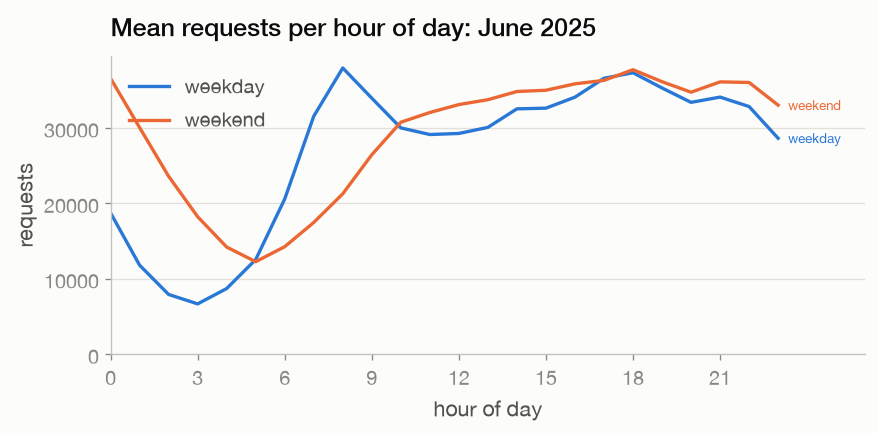

In [12]:
fig, ax = plt.subplots(figsize=(7.5, 3.8))
for i, col in enumerate(["weekday", "weekend"]):
    ax.plot(hourly.hour_of_day, hourly[col], color=vizstyle.SERIES[i], label=col)
    ax.annotate(col, (hourly.hour_of_day.iloc[-1], hourly[col].iloc[-1]),
                xytext=(6, 0), textcoords="offset points",
                color=vizstyle.SERIES[i], va="center", fontsize=8)

ax.set_title("Mean requests per hour of day: June 2025")
ax.set_xlabel("hour of day"); ax.set_ylabel("requests")
ax.set_xticks(range(0, 24, 3)); ax.set_xlim(0, 26); ax.set_ylim(bottom=0)
ax.legend(loc="upper left")
plt.tight_layout()

In [13]:
for col in ["weekday", "weekend"]:
    pk, tr = hourly[col].max(), hourly[col].min()
    print(f"{col:8} peak {pk:>7,} at {hourly.hour_of_day[hourly[col].idxmax()]:>2}:00"
          f"   trough {tr:>7,} at {hourly.hour_of_day[hourly[col].idxmin()]:>2}:00"
          f"   ratio {pk/tr:.1f}x")

weekday  peak  37,939 at  8:00   trough   6,661 at  3:00   ratio 5.7x
weekend  peak  37,707 at 18:00   trough  12,255 at  5:00   ratio 3.1x


### Findings

Mean weekday request volume ranges from 6,661 trips at 03:00 to 37,939 at 08:00, a
peak-to-trough ratio of 5.7. Mean weekend volume ranges from 12,255 trips at 05:00 to
37,707 at 18:00, a ratio of 3.1.

Peak volumes are similar across the two day types, but the weekend peak occurs ten hours
later. Overnight demand is also higher on weekends: at midnight, the mean weekend volume is
36,562 trips, compared with 18,726 on weekdays. These differences support separate weekday
and weekend demand profiles in analyses that represent the full week.

The pronounced weekday cycle creates a time-dependent relationship between trip demand,
vehicle availability, and charging. Subsequent weekday analyses represent this operating
regime and should not be interpreted as estimates of weekend conditions.

## 6. Geographic distribution of pickups

Pickup volumes are aggregated by borough to compare the geographic distribution of observed
trip origins.

In [14]:
boro = con.sql("""
SELECT z.Borough AS borough,
       count(*) AS trips,
       round(100.0 * count(*) / sum(count(*)) OVER (), 1) AS pct
FROM t JOIN z ON t.PULocationID = z.LocationID
GROUP BY 1 ORDER BY trips DESC
""").df()
boro

,borough,trips,pct
0,Manhattan,7119947,35.8
1,Brooklyn,5431031,27.3
2,Queens,4451781,22.4
3,Bronx,2540823,12.8
4,Staten Island,316414,1.6
5,N/A,912,0.0


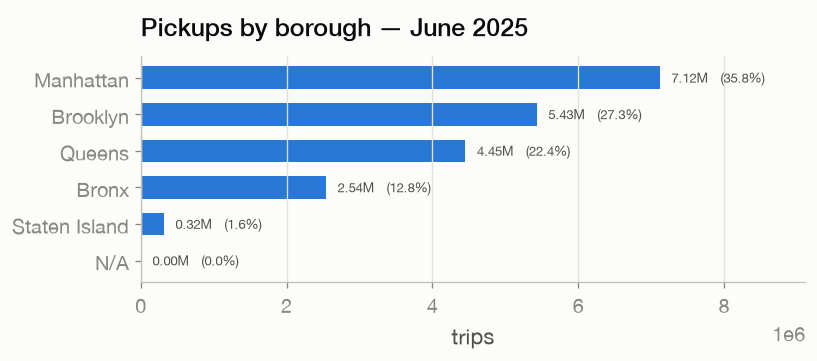

In [15]:
fig, ax = plt.subplots(figsize=(7, 3.2))
b = boro.iloc[::-1]
ax.barh(b.borough, b.trips, color=vizstyle.SERIES[0], height=0.62)
for y, (v, p) in enumerate(zip(b.trips, b.pct)):
    ax.annotate(f"{v/1e6:.2f}M   ({p}%)", (v, y), xytext=(7, 0), textcoords="offset points",
                va="center", fontsize=8, color=vizstyle.INK_SECONDARY)

ax.set_title("Pickups by borough — June 2025")
ax.set_xlabel("trips")
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
ax.set_xlim(0, b.trips.max() * 1.28)
plt.tight_layout()

### Findings

Manhattan is the largest pickup market among the five boroughs, accounting for 35.8% of
observed trips. Brooklyn accounts for 27.3%, Queens for 22.4%, the Bronx for 12.8%, and Staten
Island for 1.6%. Approximately 64% of pickups therefore originate outside Manhattan.

These results do not support selecting Manhattan solely on the basis of citywide pickup
concentration. Section 7 evaluates the proportion of trips retained within each borough, which
provides an additional criterion for selecting a service region.

## 7. Within-borough trip retention

Regional demand includes trips whose pickup and drop-off locations both fall within the service
boundary. Using each borough as a candidate boundary, the retention rate is the proportion of
trips originating in that borough that also end there.

In [16]:
internal = con.sql("""
SELECT zp.Borough AS pickup_borough,
       count(*)                                    AS trips,
       sum(zp.Borough = zd.Borough)::BIGINT        AS same_borough,
       round(100.0 * sum(zp.Borough = zd.Borough) / count(*), 1) AS pct_internal
FROM t
JOIN z zp ON t.PULocationID = zp.LocationID
JOIN z zd ON t.DOLocationID = zd.LocationID
GROUP BY 1 ORDER BY trips DESC
""").df()
internal

,pickup_borough,trips,same_borough,pct_internal
0,Manhattan,7119947,4725772,66.4
1,Brooklyn,5431031,4105830,75.6
2,Queens,4451781,2893270,65.0
3,Bronx,2540823,1853254,72.9
4,Staten Island,316414,269160,85.1
5,N/A,912,322,35.3


### Findings

| Borough | Share of volume | Internal retention |
|---|---|---|
| Brooklyn | 27.3% | **75.6%** |
| Bronx | 12.8% | 72.9% |
| Manhattan | 35.8% | 66.4% |
| Queens | 22.4% | 65.0% |
| Staten Island | 1.6% | 85.1% |

Brooklyn combines the second-largest pickup share, 27.3%, with an internal retention rate of
75.6%. Its retention rate is 9.2 percentage points higher than Manhattan's and 10.6 points
higher than Queens'. Staten Island has the highest retention rate, 85.1%, but accounts for only
1.6% of pickups. The Bronx retains 72.9% of trips and accounts for 12.8% of pickups.

At the borough scale, Brooklyn provides the strongest combination of pickup volume and internal
trip retention. Manhattan has a larger pickup market, but 33.6% of trips originating there end
outside the borough, compared with 24.4% of trips originating in Brooklyn.

These estimates apply to full-borough boundaries and do not determine retention within a smaller
service region. They also do not account for street-network characteristics, travel times, or
other operational constraints.

In [17]:
con.sql("""
SELECT z.Zone AS zone, z.Borough AS borough, count(*) AS trips
FROM t JOIN z ON t.PULocationID = z.LocationID
GROUP BY 1, 2 ORDER BY trips DESC LIMIT 15
""").df()

,zone,borough,trips
0,LaGuardia Airport,Queens,436637
1,JFK Airport,Queens,344106
2,Crown Heights North,Brooklyn,262067
3,Times Sq/Theatre District,Manhattan,234570
4,Bushwick South,Brooklyn,228481
5,Midtown Center,Manhattan,225007
6,East Village,Manhattan,222380
7,East New York,Brooklyn,221149
8,TriBeCa/Civic Center,Manhattan,212717
9,Williamsburg (North Side),Brooklyn,204501


### Concentration among high volume zones

LaGuardia Airport and John F. Kennedy International Airport are the two highest volume pickup zones,
with approximately 437,000 and 344,000 June pickups. Their inclusion materially increases the demand
attributed to Queens.

Six of the 15 highest volume zones are in Brooklyn: Crown Heights North, Bushwick South, East New York,
Williamsburg, Greenpoint, and Park Slope. Brooklyn's high volume pickups are therefore distributed
across several neighborhoods rather than concentrated in one dominant zone.

High volume Manhattan zones are concentrated in Midtown and Lower Manhattan, including Times Square,
Midtown Center, East Village, TriBeCa, Hudson Yards, East Chelsea, and Union Square.

## 8. Spatial distribution of pickup volume

Pickup counts are highly skewed across taxi zones. The map groups zones into six classes based on
pickup volume, with approximately the same number of zones in each class. Zones with no recorded
pickups are shown in gray.

In [18]:
zones = gpd.read_file(f"/vsizip/{(RAW / 'taxi_zones.zip').resolve()}/taxi_zones/taxi_zones.shp")
vol = con.sql("SELECT PULocationID AS LocationID, count(*) AS trips FROM t GROUP BY 1").df()
zones = zones.merge(vol, on="LocationID", how="left")
zones.loc[zones.trips.isna() | (zones.trips == 0), "trips"] = float("nan")
print(f"{len(zones)} zones · {int(zones.trips.notna().sum())} with pickups · CRS {zones.crs.to_string()}")
zones[["LocationID", "zone", "borough", "trips"]].sort_values("trips", ascending=False).head()

263 zones · 260 with pickups · CRS EPSG:2263


,LocationID,zone,borough,trips
137,138,LaGuardia Airport,Queens,436637.0
131,132,JFK Airport,Queens,344106.0
60,61,Crown Heights North,Brooklyn,262067.0
229,230,Times Sq/Theatre District,Manhattan,234570.0
36,37,Bushwick South,Brooklyn,228481.0


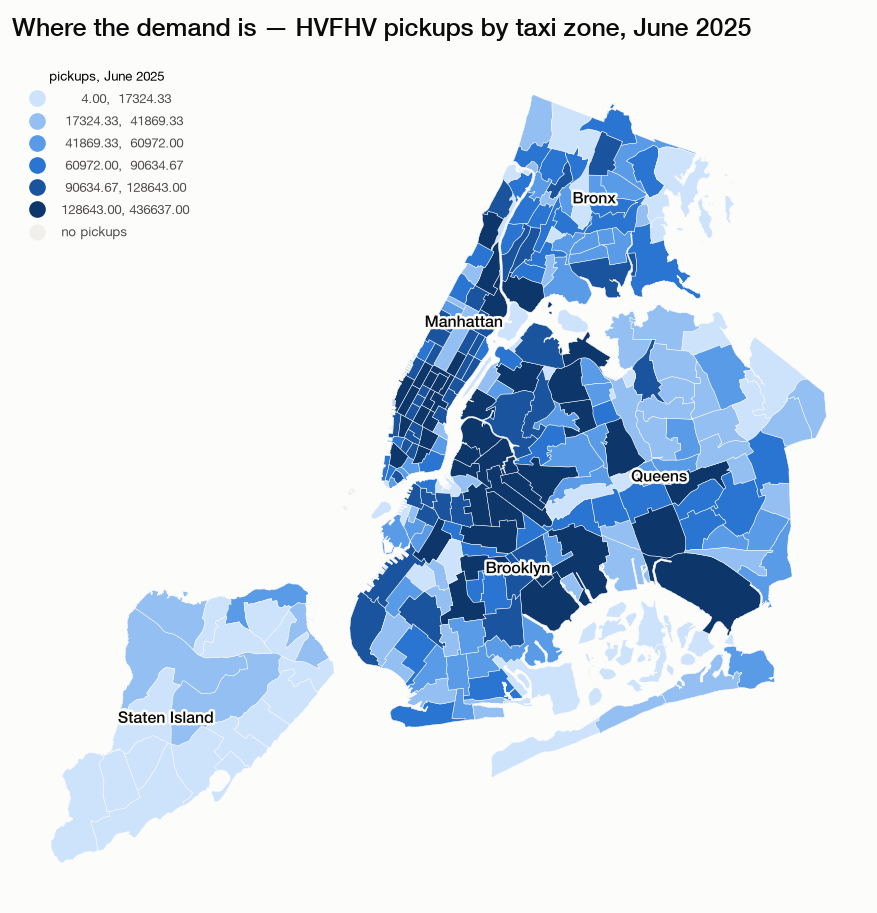

In [19]:
plot = zones[zones.borough != "EWR"]

fig, ax = plt.subplots(figsize=(7.5, 8.5))
plot.plot(column="trips", cmap=vizstyle.BLUES, ax=ax,
          scheme="Quantiles", k=6,
          linewidth=0.3, edgecolor=vizstyle.SURFACE,
          legend=True,
          legend_kwds={"title": "pickups, June 2025", "loc": "upper left",
                       "fontsize": 8, "title_fontsize": 8, "frameon": False},
          missing_kwds={"color": "#f0efec", "edgecolor": vizstyle.SURFACE,
                        "linewidth": 0.3, "label": "no pickups"})

# representative_point() stays inside the polygon; a centroid can land in the water.
for boro_name in plot.borough.unique():
    pt = plot[plot.borough == boro_name].geometry.union_all().representative_point()
    ax.annotate(boro_name, (pt.x, pt.y), ha="center", fontsize=9.5,
                color=vizstyle.INK, weight="medium",
                path_effects=[pe.withStroke(linewidth=3, foreground=vizstyle.SURFACE)])

ax.set_axis_off()
ax.set_title("Where the demand is — HVFHV pickups by taxi zone, June 2025")
plt.tight_layout()

## 9. Origin and destination structure

The public trip records identify pickup and dropoff taxi zones rather than coordinates. Each
trip is therefore represented by an ordered pair of zone identifiers, and its location within
either zone cannot be recovered from these data.

Travel time and distance are represented at the level of origin and destination zones. This
section examines matrix coverage, zone area, flows between boroughs, spatial imbalance by time
of day, and trip flows within Brooklyn.

In [20]:
con.sql("""
          SELECT 'OD pairs (PU,DO)'   AS column, count(DISTINCT (PULocationID, DOLocationID)) AS n_unique FROM t
UNION ALL SELECT 'DOLocationID',                 count(DISTINCT DOLocationID)         FROM t
UNION ALL SELECT 'PULocationID',                 count(DISTINCT PULocationID)         FROM t
UNION ALL SELECT 'originating_base_num',         count(DISTINCT originating_base_num) FROM t
UNION ALL SELECT 'hvfhs_license_num',            count(DISTINCT hvfhs_license_num)    FROM t
UNION ALL SELECT 'dispatching_base_num',         count(DISTINCT dispatching_base_num) FROM t
UNION ALL SELECT 'shared_request_flag',          count(DISTINCT shared_request_flag)  FROM t
UNION ALL SELECT 'wav_match_flag',               count(DISTINCT wav_match_flag)       FROM t
ORDER BY n_unique DESC
""").df()

,column,n_unique
0,"OD pairs (PU,DO)",60749
1,DOLocationID,263
2,PULocationID,261
3,originating_base_num,5
4,hvfhs_license_num,2
5,dispatching_base_num,2
6,shared_request_flag,2
7,wav_match_flag,2


In [21]:
flags = ["shared_request_flag", "shared_match_flag", "access_a_ride_flag",
         "wav_request_flag", "wav_match_flag"]
pd.concat([
    con.sql(f'SELECT \'{f}\' AS flag, "{f}" AS value, count(*) AS trips, '
            f'round(100.0*count(*)/sum(count(*)) OVER (), 2) AS pct '
            f'FROM t GROUP BY 1,2').df()
    for f in flags
]).query("value == 'Y'").reset_index(drop=True)

,flag,value,trips,pct
0,shared_request_flag,Y,626617,3.16
1,shared_match_flag,Y,366825,1.85
2,access_a_ride_flag,Y,21706,0.11
3,wav_request_flag,Y,61871,0.31
4,wav_match_flag,Y,1719760,8.66


### Matrix coverage and service flags

The June sample contains 60,749 distinct origin and destination pairs, or 88.5% of the 68,643
possible pairs formed by the observed pickup and dropoff zones. Dividing these pairs into 24
hourly intervals produces about 1.46 million possible cells and an average of 13.6 trips per
cell. Counts are not distributed uniformly, so many cells contain few observations.

Aggregation to approximately 20 analysis zones would reduce the matrix to 9,600 possible cells
across 24 hours. This would reduce sparsity while also reducing spatial detail.

`dispatching_base_num` contains two distinct values, and `originating_base_num` contains five.
These fields do not provide sufficient detail for spatial dispatch analysis. Shared service was
requested for 3.16% of trips and matched for 1.85%. Access A Ride requests account for 0.11%,
while wheelchair accessible service was requested for 0.31% and matched for 8.66%. The current
model does not distinguish pooled or wheelchair accessible service.

In [22]:
zg = gpd.read_file(f"/vsizip/{(RAW / 'taxi_zones.zip').resolve()}/taxi_zones/taxi_zones.shp")
zg["sq_mi"] = zg.geometry.area / 27_878_400        # EPSG:2263 is in feet
zg.groupby("borough").sq_mi.agg(["count", "min", "median", "max"]).round(2)

,count,min,median,max
borough,,,,
Bronx,43,0.23,0.69,3.54
Brooklyn,61,0.16,0.98,4.20
EWR,1,2.84,2.84,2.84
Manhattan,69,0.02,0.27,1.37
Queens,69,0.07,1.53,7.03
Staten Island,20,0.84,2.14,7.59


### Variation in taxi zone area

Taxi zone area differs substantially across boroughs. The median zone covers 0.27 square miles
in Manhattan, 0.98 in Brooklyn, and 1.53 in Queens. The largest Queens zone covers 7.03 square
miles.

This variation affects the spatial resolution of any aggregation. Grouping the same number of
taxi zones can produce analysis zones with very different physical areas. The travel matrix
retains observed distance and duration for trips that begin and end in the same analysis zone,
so these trips remain represented on the matrix diagonal. Zone area should therefore inform the
aggregation procedure, but it does not by itself identify a preferred borough.

### Flows between boroughs

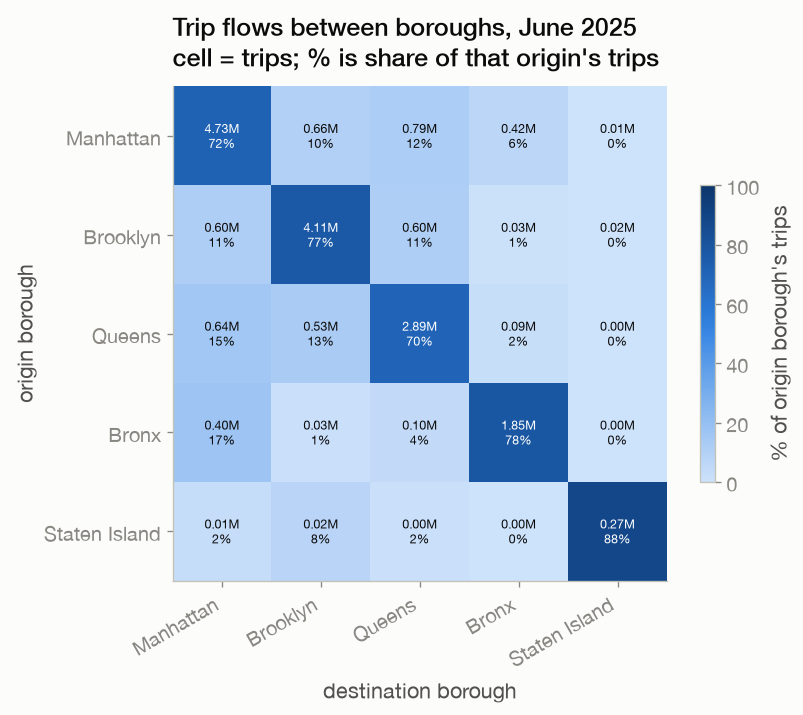

In [23]:
REAL = ("zp.Borough NOT IN ('Unknown','N/A','EWR') AND "
        "zd.Borough NOT IN ('Unknown','N/A','EWR')")
od = con.sql(f"""
SELECT zp.Borough AS o, zd.Borough AS d, count(*) AS n
FROM t JOIN z zp ON t.PULocationID = zp.LocationID
       JOIN z zd ON t.DOLocationID = zd.LocationID
WHERE {REAL} GROUP BY 1, 2
""").df()

order = ["Manhattan", "Brooklyn", "Queens", "Bronx", "Staten Island"]
M = od.pivot(index="o", columns="d", values="n").reindex(index=order, columns=order).fillna(0)
row_pct = M.div(M.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(7.2, 6))
im = ax.imshow(row_pct.values, cmap=vizstyle.BLUES, vmin=0, vmax=100)
ax.set_xticks(range(len(order)), order, rotation=30, ha="right")
ax.set_yticks(range(len(order)), order)
for i in range(len(order)):
    for j in range(len(order)):
        v, p = M.values[i, j], row_pct.values[i, j]
        ax.text(j, i, f"{v/1e6:.2f}M\n{p:.0f}%", ha="center", va="center", fontsize=7.5,
                color="white" if p > 50 else vizstyle.INK)
ax.set_xlabel("destination borough"); ax.set_ylabel("origin borough")
ax.set_title("Trip flows between boroughs, June 2025\ncell = trips; % is share of that origin's trips")
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.6, label="% of origin borough's trips")
plt.tight_layout()

Brooklyn retains 76.7% of trips after records with destinations coded as EWR, Unknown, or N/A
are excluded. The corresponding shares are 71.6% for Manhattan and 69.7% for Queens.

These values differ from Section 7 because that analysis includes all destination codes. The
exclusions increase the estimated retention rate by 5.2 percentage points for Manhattan and 1.1
points for Brooklyn. Destination coding therefore has a larger effect on the Manhattan estimate.

### Net trip flow by taxi zone

Net trip flow is defined as arrivals minus departures within each taxi zone. It is calculated
for the weekday morning period from 07:00 to 10:00 and the evening period from 17:00 to 20:00.
Positive values indicate more arrivals than departures, while negative values indicate more
departures than arrivals. This measure describes directional imbalance in passenger trips. It
does not include vehicle movements without passengers.

Text(0.015, 0.955, 'June 2025 weekdays · color scale clipped at the 97th percentile')

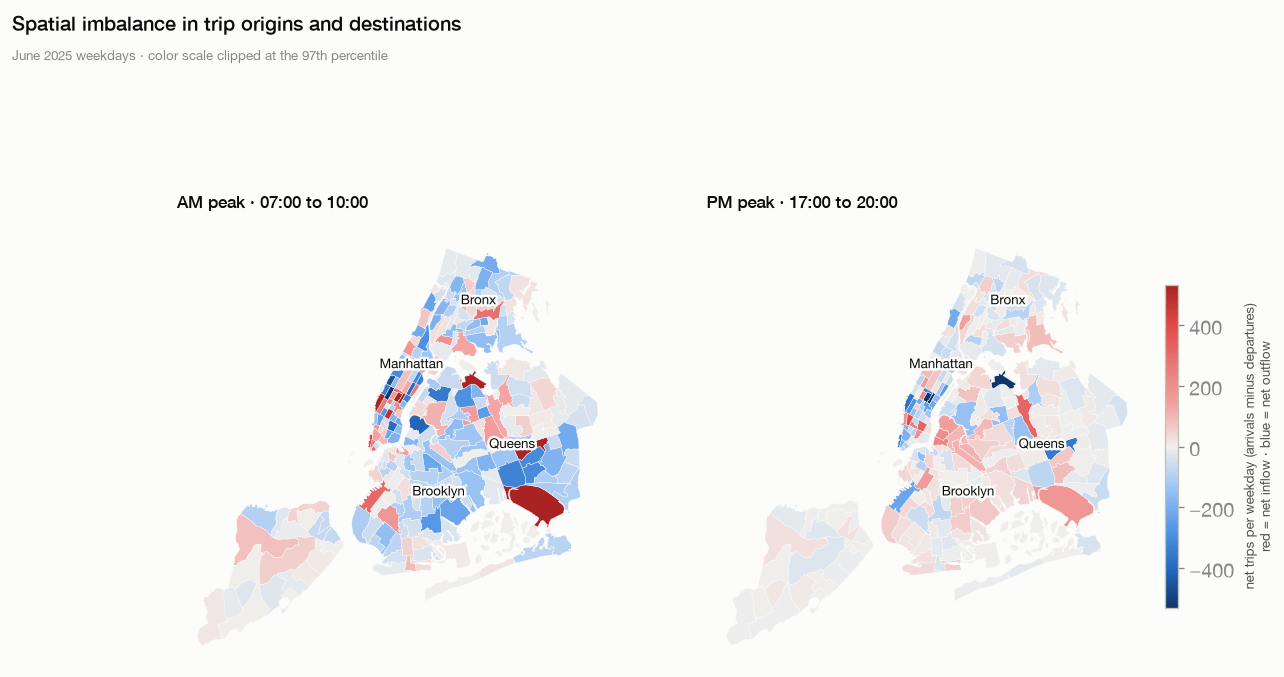

In [24]:
zmap = zg[zg.borough != "EWR"]

def netflow(lo, hi):
    return con.sql(f"""
    WITH win AS (SELECT * FROM t
                 WHERE dayofweek(request_datetime) BETWEEN 1 AND 5
                   AND hour(request_datetime) >= {lo} AND hour(request_datetime) < {hi}),
    dep AS (SELECT PULocationID id, count(*) n FROM win GROUP BY 1),
    arr AS (SELECT DOLocationID id, count(*) n FROM win GROUP BY 1)
    SELECT coalesce(dep.id, arr.id) AS LocationID,
           (coalesce(arr.n, 0) - coalesce(dep.n, 0)) / 21.0 AS net_per_day
    FROM dep FULL OUTER JOIN arr ON dep.id = arr.id """).df()

panels = [("AM peak · 07:00 to 10:00", netflow(7, 10)), ("PM peak · 17:00 to 20:00", netflow(17, 20))]
lim = max(np.percentile(np.abs(p[1].net_per_day), 97) for p in panels)
norm = TwoSlopeNorm(vmin=-lim, vcenter=0, vmax=lim)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 7))
for ax, (title, nf) in zip(axes, panels):
    g = zmap.merge(nf, on="LocationID", how="left")
    g["net_per_day"] = g.net_per_day.fillna(0)
    g.plot(column="net_per_day", cmap=vizstyle.DIVERGING, norm=norm, ax=ax,
           linewidth=0.25, edgecolor=vizstyle.SURFACE)
    ax.set_axis_off(); ax.set_title(title, fontsize=10)
    for b in ["Manhattan", "Brooklyn", "Queens", "Bronx"]:
        pt = g[g.borough == b].geometry.union_all().representative_point()
        ax.annotate(b, (pt.x, pt.y), ha="center", fontsize=8, color=vizstyle.INK,
                    path_effects=[pe.withStroke(linewidth=3, foreground=vizstyle.SURFACE)])

sm = plt.cm.ScalarMappable(cmap=vizstyle.DIVERGING, norm=norm)
cb = fig.colorbar(sm, ax=axes, shrink=0.5, aspect=26, pad=0.015)
cb.set_label("net trips per weekday (arrivals minus departures)\nred = net inflow · blue = net outflow",
             fontsize=8)
fig.text(0.015, 0.99, "Spatial imbalance in trip origins and destinations",
         fontsize=12, weight="medium", color=vizstyle.INK)
fig.text(0.015, 0.955, "June 2025 weekdays · color scale clipped at the 97th percentile",
         fontsize=8, color=vizstyle.INK_MUTED)

In [25]:
for title, nf in panels:
    m = nf.merge(zg[["LocationID", "zone"]], on="LocationID")
    print(title)
    print("  highest net inflow:", ", ".join(
        m.nlargest(4, "net_per_day").apply(lambda r: f"{r['zone']} +{r.net_per_day:.0f}", axis=1)))
    print("  highest net outflow:", ", ".join(
        m.nsmallest(4, "net_per_day").apply(lambda r: f"{r['zone']} {r.net_per_day:.0f}", axis=1)))

AM peak · 07:00 to 10:00
  highest net inflow: Midtown Center +1790, LaGuardia Airport +1588, Midtown East +1180, JFK Airport +1053
  highest net outflow: Clinton East -522, Lincoln Square West -461, Greenpoint -415, Lenox Hill West -396
PM peak · 17:00 to 20:00
  highest net inflow: Newark Airport +512, West Village +397, East Village +324, Flushing Meadows-Corona Park +319
  highest net outflow: LaGuardia Airport -1111, Midtown Center -817, Midtown East -535, West Chelsea/Hudson Yards -372


### Findings

During the morning period, Midtown Center records 1,790 more arrivals than departures per
weekday, and LaGuardia Airport records 1,588 more. During the evening period, Midtown Center
records 817 more departures than arrivals, and LaGuardia Airport records 1,111 more.

The reversal indicates that passenger trips redistribute vehicle locations over the course of
the day. Repositioning decisions can respond to this imbalance, although the trip records do not
show how providers actually reposition vehicles.

### Internal trip flows in Brooklyn

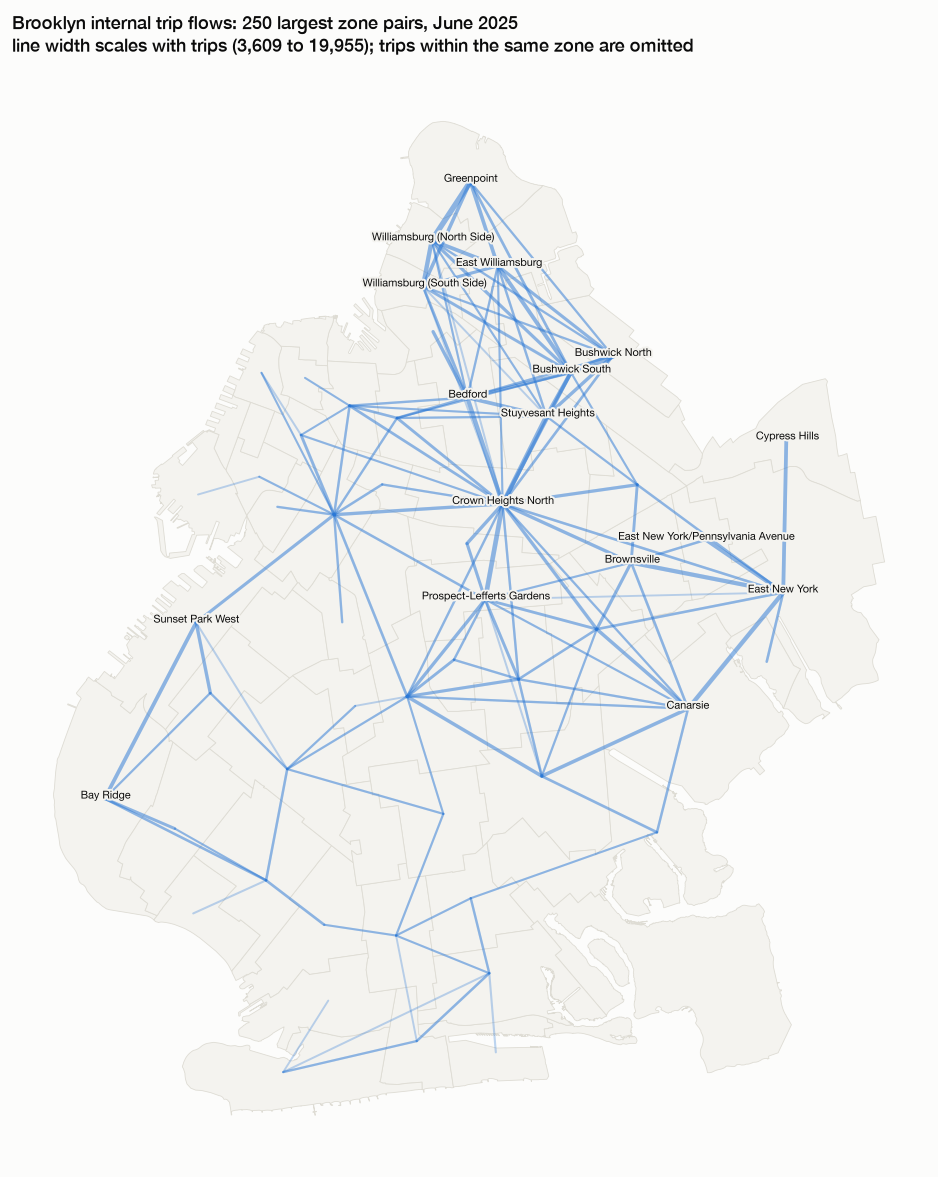

In [26]:
flows = con.sql("""
SELECT t.PULocationID o, t.DOLocationID d, count(*) n
FROM t JOIN z zp ON t.PULocationID = zp.LocationID
       JOIN z zd ON t.DOLocationID = zd.LocationID
WHERE zp.Borough = 'Brooklyn' AND zd.Borough = 'Brooklyn'
  AND t.PULocationID <> t.DOLocationID
GROUP BY 1, 2 ORDER BY n DESC LIMIT 250
""").df()

bk = zg[zg.borough == "Brooklyn"]
cen = {r.LocationID: r.geometry.representative_point() for r in bk.itertuples()}

fig, ax = plt.subplots(figsize=(9.5, 10))
bk.plot(ax=ax, color="#f4f3ef", edgecolor="#dedcd4", linewidth=0.5)
mx = flows.n.max()
for r in flows.itertuples():
    a, b = cen.get(r.o), cen.get(r.d)
    if a is None or b is None:
        continue
    ax.plot([a.x, b.x], [a.y, b.y], color=vizstyle.SERIES[0],
            linewidth=0.25 + 3.2 * (r.n / mx) ** 0.75, alpha=0.30,
            solid_capstyle="round", zorder=2)

for r in bk[bk.LocationID.isin(flows.head(30).o)].itertuples():
    ax.annotate(r.zone, (cen[r.LocationID].x, cen[r.LocationID].y), fontsize=6.5, ha="center",
                color=vizstyle.INK, zorder=3,
                path_effects=[pe.withStroke(linewidth=2.4, foreground="#f4f3ef")])

ax.set_axis_off()
ax.set_title("Brooklyn internal trip flows: 250 largest zone pairs, June 2025\n"
             f"line width scales with trips ({flows.n.min():,} to {mx:,}); "
             "trips within the same zone are omitted", fontsize=10.5)
plt.tight_layout()

### Interpretation

The 250 largest flows between distinct Brooklyn taxi zones show several geographic groups.
These include Williamsburg, Greenpoint, and Bushwick in the north; Bay Ridge and Sunset Park in
the west; and Canarsie, East New York, and Brownsville in the east. Crown Heights North appears
in several of the largest flows.

Observed trip volumes provide one input for aggregating taxi zones into analysis zones. A formal
aggregation procedure can combine flow volume with geographic continuity and limits on physical
area.

The lines connect representative points for each taxi zone and encode trip volume. They do not
represent traveled routes. Trips that begin and end in the same taxi zone are omitted from the
figure. These trips account for 21% of trips among Brooklyn's 25 highest volume zones.

## 10. Summary

1. The June file contains 19.87 million trip records. Basic validity filters retain 99.96% of
   these records. Request, vehicle arrival, and pickup timestamps are complete in the analyzed
   fields, which allows observed wait time to be calculated directly.
2. Mean hourly weekday request volume ranges from 6,661 to 37,939 trips, a ratio of 5.7. Weekend
   volume ranges from 12,255 to 37,707, with the peak occurring ten hours later than on weekdays.
3. Manhattan accounts for 35.8% of pickups, Brooklyn for 27.3%, Queens for 22.4%, the Bronx for
   12.8%, and Staten Island for 1.6%.
4. Brooklyn retains 75.6% of trips that originate within the borough. The corresponding rates are
   66.4% for Manhattan and 65.0% for Queens. These estimates apply to full borough boundaries.
5. LaGuardia and JFK are the two highest volume pickup zones. Their inclusion has a substantial
   effect on the demand attributed to Queens.
6. The sample contains 60,749 distinct origin and destination pairs. Hourly disaggregation creates
   sparse cells, while spatial aggregation changes both matrix density and physical resolution.
7. Net trip flow changes between the morning and evening periods. This pattern indicates that
   passenger trips redistribute vehicle locations over the course of the day.

### Scope and interpretation

At the borough scale, Brooklyn provides the strongest observed combination of pickup volume and
internal retention. This comparison does not identify the best boundary within a borough or
account for every operational constraint. Weekday and weekend demand profiles represent distinct
temporal regimes. Estimates for Queens depend materially on whether airport zones are included.

### Demand measurement limitation

The analysis estimates demand rates from recorded trips. Requests that do not result in a
recorded trip are absent, so latent demand is unavailable. Estimated rates therefore represent
realized demand and may reflect supply constraints or other forms of marketplace censoring. A
later extension could estimate uncensored demand if request, cancellation, and supply data become
available.

### Data limitation

The trip records contain passenger trips only. Vehicle movements associated with pickup approach
and repositioning are not observed. Applying the travel matrix to movements without passengers
assumes that travel time and distance are comparable after conditioning on origin, destination,
and hour. This assumption cannot be evaluated from the trip records.

### Subsequent analyses

Notebook 02 examines temporal and spatial demand structure and estimates a lower bound on
repositioning. Notebook 03 evaluates heat related changes in travel time using matched day types.
Notebook 04 constructs Brooklyn analysis zones and estimates travel time and distance by origin,
destination, and hour. Notebook 05 estimates demand rates, fleet size, and capture share.

## 11. Retained modeling tradeoffs

The subsequent model retains the following choices. Each improves estimation or keeps the operating
model internally consistent, while limiting the conclusions that can be drawn from it.

| Choice | Reason retained | Consequence |
|---|---|---|
| Pool Uber and Lyft records | The study models aggregate HVFHV demand and gains support in spatial and hourly cells. | Provider specific demand, service quality, and operating behavior are not represented. |
| Use Brooklyn as a closed service region | Brooklyn combines high pickup volume with 75.6 percent internal trip retention, and a closed region is consistent with the later travel matrix. | Approximately 24.4 percent of trips originating in Brooklyn end elsewhere. Trips entering Brooklyn, cross boundary vehicle movements, and their energy and repositioning effects are excluded. |
| Calibrate from completed trips | Completed trips provide request time, origin, destination, duration, and distance in one consistent source. | Rejected, canceled, abandoned, and otherwise unserved requests are absent. Estimated rates may reflect supply constraints and do not measure latent demand. |
| Use a post congestion pricing summer window | June and July remain within one recent regulatory regime and provide more observations than one month. | Seasonal conditions are narrow, and the estimates do not establish winter demand or travel behavior. |
| Treat capture share as a scenario input | Unique vehicles cannot be deduplicated across providers, and monthly vehicle counts do not measure simultaneous fleet availability. | The modeled share of demand and implied fleet load are assumptions rather than estimates of observed market share or utilization. |
| Aggregate taxi zones in later fits | Fewer spatial units improve origin, destination, and hour cell support. | Aggregation reduces spatial resolution and conceals variation within a decision zone. Notebook 04 measures this loss for travel inputs. |

These consequences carry into the demand and travel artifacts. They are addressed where possible by
sensitivity analysis, but they remain part of the interpretation of policy evaluation results.